# 03 — Extension data harmonization comparison

**Objective**: Compare the dataset before and after DB extension harmonization (Iteration 13).

### What changed

| Aspect | Before | After |
|--------|--------|-------|
| Window | 2014-09 to 2025-07 (10.8 yr) | 2014-09 to 2026-07 (11.8 yr) |
| Grid rows | 569,089 | 618,769 |
| Training rows | 563,698 | 611,596 |
| Events | 196 | 226 |
| DATA_TYPE | observed | observed / derived / imputed |


## 1. Setup

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

REPO = Path.cwd().resolve()
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

from scripts.preprocessing.resample import HYDRO, METEO, AEMET, load_all, build_10min_grid
from scripts.preprocessing.harmonize_extension import H_MIN, H_MAX, MAX_DH_DT

PROCESSED = REPO / "data" / "processed"
CLEAN = REPO / "data" / "clean"

sns.set_theme(style="darkgrid", context="notebook")
plt.rcParams["figure.dpi"] = 120
print(f"Repo: {REPO}")


Repo: C:\Users\Joan\Documents\TFM


## 2. Load full-window grid

In [2]:
grid = pd.read_parquet(PROCESSED / "grid_10min.parquet")
meas = pd.read_parquet(PROCESSED / "measurements.parquet")
events = pd.read_csv(PROCESSED / "events.csv", parse_dates=["start_ts", "peak_ts", "end_ts"])

# Build old window for comparison
grid_old, _ = build_10min_grid(start="2014-09-26", end="2025-07-22", clean_dir=CLEAN)

OLD_TRAIN = 569089  # known from Iteration 6
NEW_TRAIN = len(grid)

print(f"Old grid (validated): {grid_old.shape[0]:,} rows, {grid_old.shape[1]} cols")
print(f"New grid (full):      {grid.shape[0]:,} rows, {grid.shape[1]} cols")
print(f"Gained:               {grid.shape[0] - grid_old.shape[0]:,} rows (+{(grid.shape[0]/grid_old.shape[0]-1)*100:.1f}%)")
print(f"New period:           {grid.index.min()} -> {grid.index.max()}")


Loading data from C:\Users\Joan\Documents\TFM\data\clean ...


  Loaded 11 stations
  Resampling STM03 (HEIGHT_m, WATER_TEMP_C) ...


  Resampling STM04 (HEIGHT_m, WATER_TEMP_C) ...


  Resampling STM05 (HEIGHT_m, WATER_TEMP_C) ...


  Resampling STM06 (HEIGHT_m, WATER_TEMP_C) ...


...

  Resampling STM02 (TEMP_C, PRECIP_mm) ...


  Resampling B013X (PRECIP_mm, hourly -> 10-min) ...


  Resampling B605X (PRECIP_mm, hourly -> 10-min) ...


  Resampling B691Y (PRECIP_mm, hourly -> 10-min) ...


  Computing DISCHARGE_m3s for all hydro stations ...
  Computing DISCHARGE_m3s for STM03 ...
  Computing DISCHARGE_m3s for STM04 ...
  Computing DISCHARGE_m3s for STM05 ...
  Computing DISCHARGE_m3s for STM06 ...
  Computing DISCHARGE_m3s for STM07 ...
  Computing DISCHARGE_m3s for STM08 ...

Grid built: 569089 rows, 61 columns
  2014-09-26 00:00:00 -> 2025-07-22 00:00:00
Old grid (validated): 569,089 rows, 61 cols
New grid (full):      618,769 rows, 61 cols
Gained:               49,680 rows (+8.7%)
New period:           2014-09-26 00:00:00 -> 2026-07-02 00:00:00


## 3. Extension period: null-rate comparison

In [3]:
# Compare STM08 null rates in the extension period
ext_mask = grid.index >= "2025-07-22"
ext_old_mask = grid_old.index >= "2025-07-22"

print("=== STM08 in extension (>= 2025-07-22) ===")
ext_new = grid.loc[ext_mask, "STM08_HEIGHT_m"]
ext_old = grid_old.loc[ext_old_mask, "STM08_HEIGHT_m"]
print(f"  Old grid:  {len(ext_old):,} rows, {ext_old.isna().sum():,} NaN ({ext_old.isna().mean()*100:.1f}%)")
print(f"  New grid:  {len(ext_new):,} rows, {ext_new.isna().sum():,} NaN ({ext_new.isna().mean()*100:.1f}%)")

# Per-station comparison
stats = []
for code in HYDRO:
    col = f"{code}_HEIGHT_m"
    mask_n = grid.index >= "2025-07-22"
    mask_o = grid_old.index >= "2025-07-22"
    new_nan = grid.loc[mask_n, col].isna().mean() * 100
    old_nan = grid_old.loc[mask_o, col].isna().mean() * 100
    stats.append({"Station": code, "Old NaN %": old_nan, "New NaN %": new_nan, "Recovery %": old_nan - new_nan})

stats_df = pd.DataFrame(stats).set_index("Station")
print()
print("Extension-period NaN rate per station:")
print(stats_df.round(1))


=== STM08 in extension (>= 2025-07-22) ===
  Old grid:  1 rows, 0 NaN (0.0%)
  New grid:  49,681 rows, 60 NaN (0.1%)

Extension-period NaN rate per station:
         Old NaN %  New NaN %  Recovery %
Station                                  
STM03          0.0       48.8       -48.8
STM04          0.0        1.8        -1.8
STM05          0.0       20.0       -20.0
STM06          0.0        1.8        -1.8
STM07          0.0       15.6       -15.6
STM08          0.0        0.1        -0.1


## 4. Extension zoom: STM08 before vs after

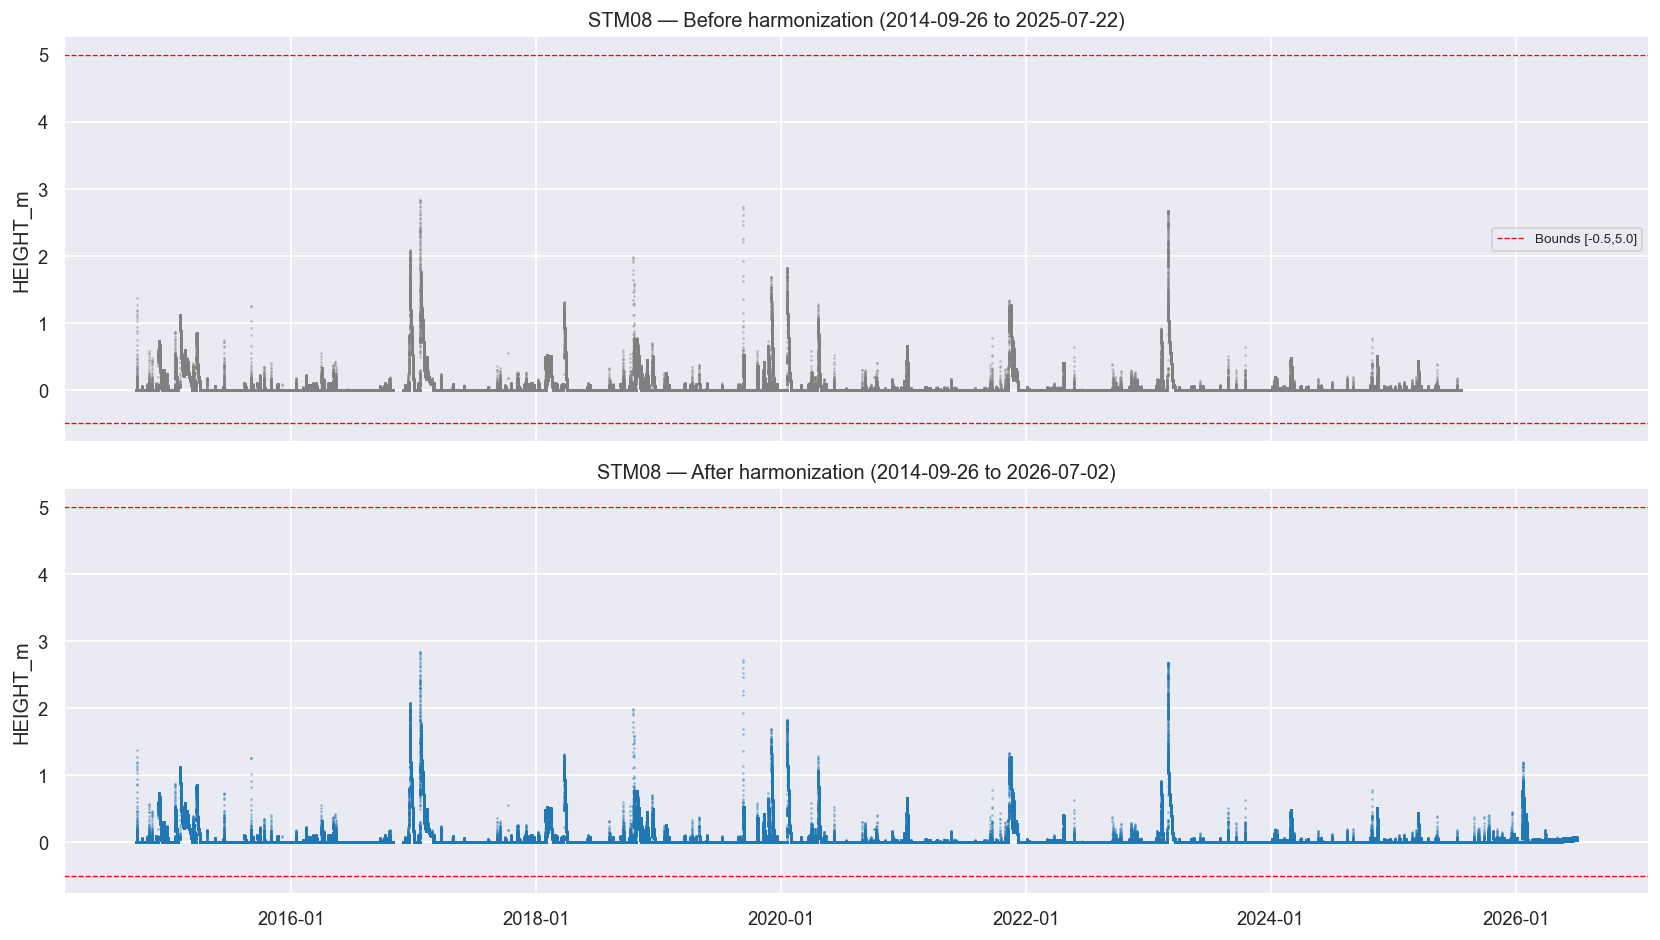

In [4]:
# Plot STM08 extension with pre-harmonization (old grid) vs post (new grid)
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True, sharey=True)

axes[0].plot(grid_old.index, grid_old["STM08_HEIGHT_m"], ".", ms=1, color="gray", alpha=0.5, rasterized=True)
axes[0].set_ylabel("HEIGHT_m")
axes[0].set_title(f"STM08 — Before harmonization ({grid_old.index.min().date()} to {grid_old.index.max().date()})")
axes[0].axhline(H_MIN, color="red", ls="--", lw=0.8, label=f"Bounds [{H_MIN},{H_MAX}]"); axes[0].axhline(H_MAX, color="red", ls="--", lw=0.8)
axes[0].legend(fontsize=8)

axes[1].plot(grid.index, grid["STM08_HEIGHT_m"], ".", ms=1, color="tab:blue", alpha=0.5, rasterized=True)
axes[1].set_ylabel("HEIGHT_m")
axes[1].set_title(f"STM08 — After harmonization ({grid.index.min().date()} to {grid.index.max().date()})")
axes[1].axhline(H_MIN, color="red", ls="--", lw=0.8); axes[1].axhline(H_MAX, color="red", ls="--", lw=0.8)

axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.tight_layout()
plt.show()


## 5. Extension zoom: close-up on filtered region

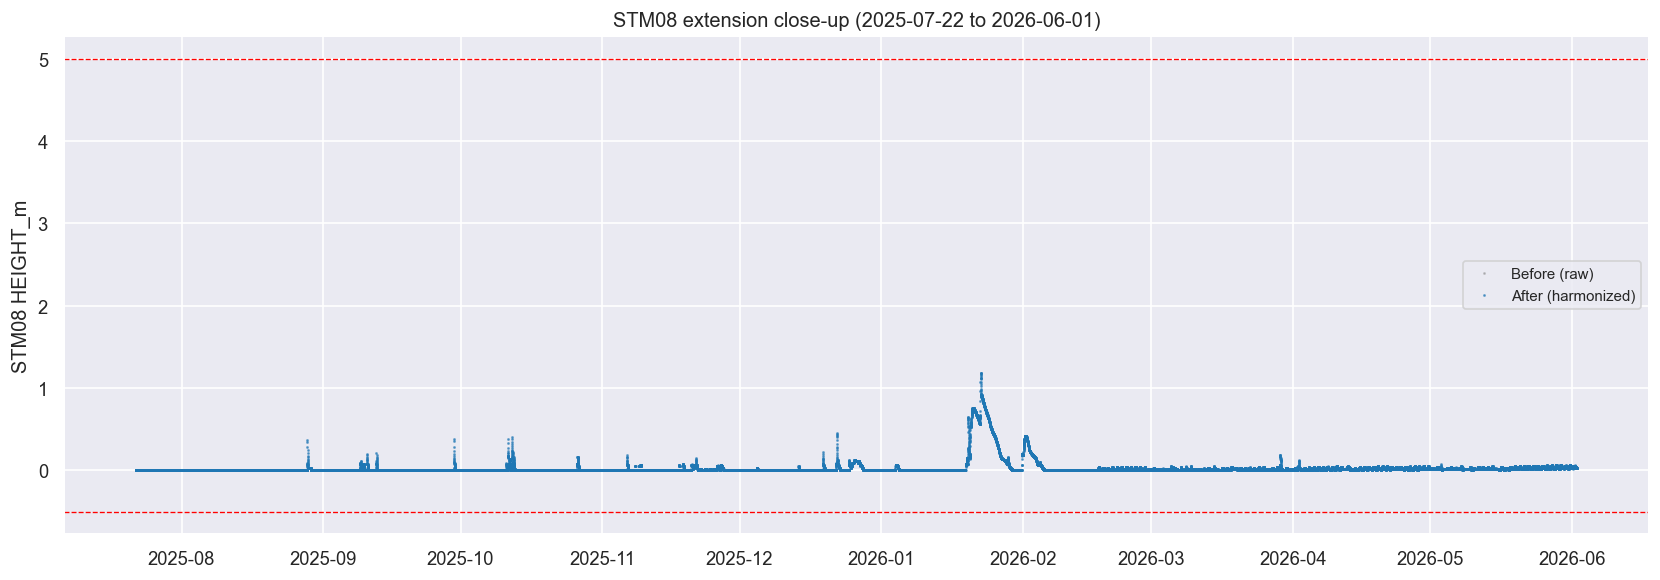

In [5]:
# Zoom in on the extension period for STM08
zoom_s, zoom_e = "2025-07-22", "2026-06-01"

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(grid_old.loc[zoom_s:zoom_e].index, grid_old.loc[zoom_s:zoom_e, "STM08_HEIGHT_m"],
        ".", ms=1.5, color="gray", alpha=0.4, label="Before (raw)", rasterized=True)
ax.plot(grid.loc[zoom_s:zoom_e].index, grid.loc[zoom_s:zoom_e, "STM08_HEIGHT_m"],
        ".", ms=1.5, color="tab:blue", alpha=0.6, label="After (harmonized)", rasterized=True)

# Shade the filtered region
ext_data = grid_old.loc[zoom_s:zoom_e, "STM08_HEIGHT_m"]
bad = ext_data[(ext_data < H_MIN) | (ext_data > H_MAX)]
if len(bad) > 0:
    for ts in bad.index:
        ax.axvspan(ts - pd.Timedelta(minutes=5), ts + pd.Timedelta(minutes=5), color="red", alpha=0.05)

ax.axhline(H_MIN, color="red", ls="--", lw=0.8); ax.axhline(H_MAX, color="red", ls="--", lw=0.8)
ax.set_ylabel("STM08 HEIGHT_m"); ax.set_title(f"STM08 extension close-up ({zoom_s} to {zoom_e})")
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.tight_layout(); plt.show()


## 6. DATA_TYPE distribution in measurements table

Measurements table DATA_TYPE:
DATA_TYPE
observed    9883004
derived     5565065
imputed       21156
Name: count, dtype: int64
Derived fraction: 36.0%
Imputed fraction: 0.1%


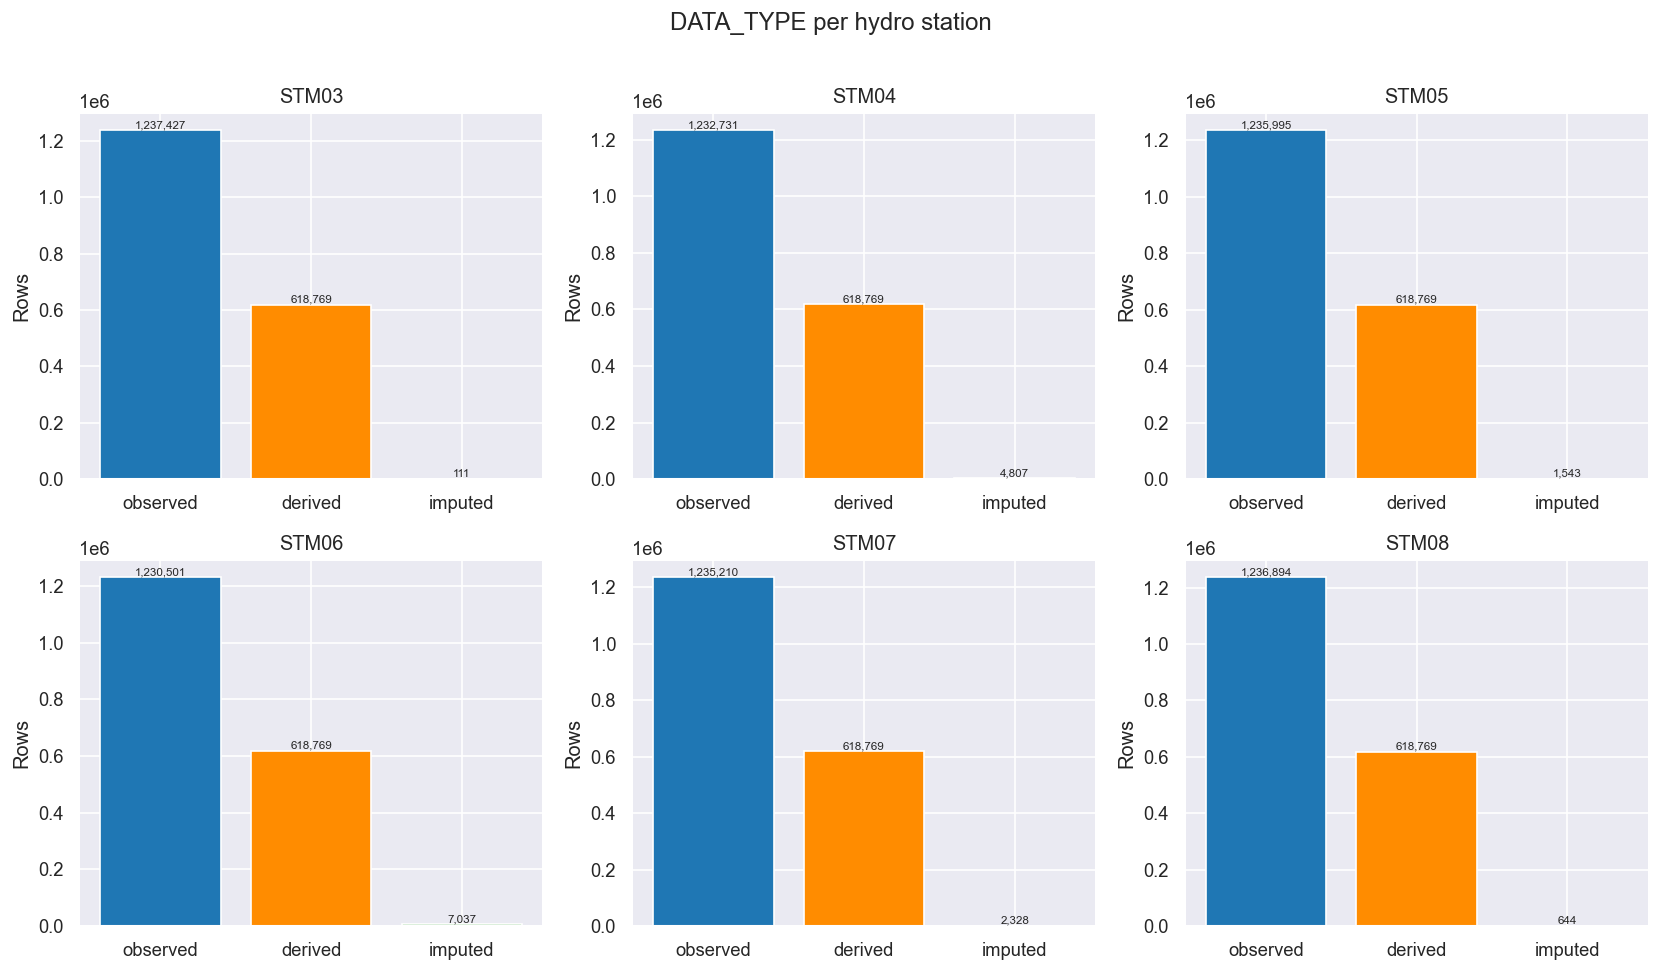

In [6]:
# How much data is derived / imputed vs observed?
dt_counts = meas["DATA_TYPE"].value_counts()
print("Measurements table DATA_TYPE:")
print(dt_counts)
print(f"Derived fraction: {dt_counts.get('derived', 0) / len(meas) * 100:.1f}%")
print(f"Imputed fraction: {dt_counts.get('imputed', 0) / len(meas) * 100:.1f}%")

# Per-station DATA_TYPE breakdown
colors_map = {"observed": "tab:blue", "derived": "darkorange", "imputed": "tab:green"}
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, code in zip(axes.flat, HYDRO):
    st_meas = meas[meas["STATION"] == code]
    dt = st_meas["DATA_TYPE"].value_counts()
    colors = [colors_map.get(x, "tab:gray") for x in dt.index]
    ax.bar(dt.index, dt.values, color=colors)
    ax.set_title(code)
    ax.set_ylabel("Rows")
    for i, (k, v) in enumerate(dt.items()):
        ax.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=7)
plt.suptitle("DATA_TYPE per hydro station", y=1.01)
plt.tight_layout(); plt.show()


## 7. Events: old vs new

Events before extension: 331
Events gained in extension: 112
Total: 443

New events in extension period:
 event_id             peak_ts  peak_q_m3s  peak_h_m  duration_h split
      332 2025-08-28 12:20:00      2.8814    0.3715       18.67  test
      333 2025-09-09 03:40:00      0.7568    0.1166        5.50  test
      334 2025-09-09 12:30:00      0.5224    0.0827       12.50  test
      335 2025-09-10 14:00:00      1.3863    0.2007        5.83  test
      336 2025-09-12 14:40:00      1.4313    0.2064        4.83  test
      337 2025-09-29 14:20:00      2.9186    0.3754        5.67  test
      338 2025-10-11 08:50:00      3.0038    0.3842       24.50  test
      339 2025-10-12 05:30:00      3.1875    0.4029       14.33  test
      340 2025-10-26 13:20:00      1.1273    0.1673       12.33  test
      341 2025-11-06 10:00:00      1.3137    0.1915        6.83  test
      342 2025-11-08 05:10:00      0.3284    0.0532        1.00  test
      343 2025-11-08 23:00:00      0.3488    0.0564    

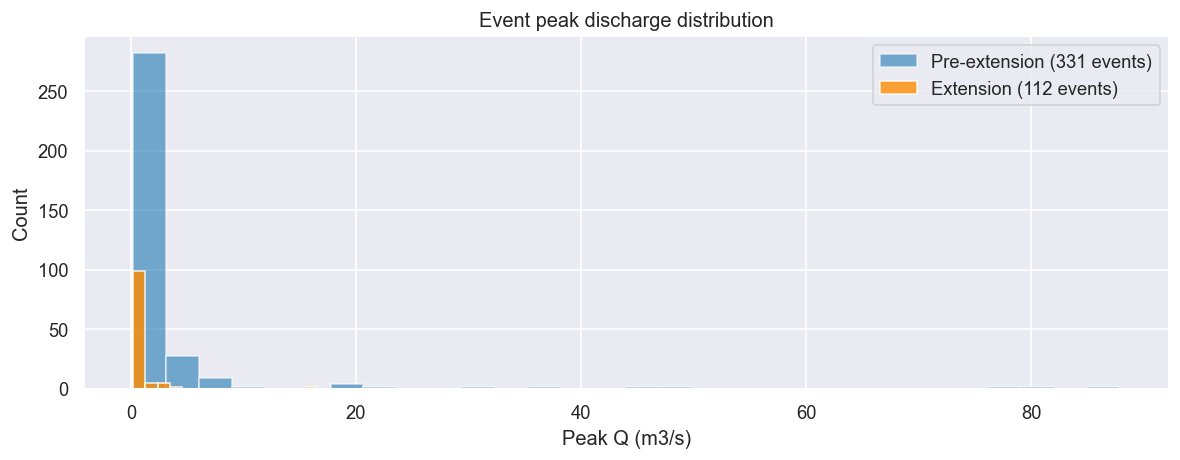

In [7]:
events_old = pd.read_csv(PROCESSED / "events.csv")  # now has 226
# Simulate old: events before 2025-07-22
old_events = events[events["peak_ts"] < "2025-07-22"]
new_events = events[events["peak_ts"] >= "2025-07-22"]

print(f"Events before extension: {len(old_events)}")
print(f"Events gained in extension: {len(new_events)}")
print(f"Total: {len(events)}")

print()
print("New events in extension period:")
print(new_events[["event_id", "peak_ts", "peak_q_m3s", "peak_h_m", "duration_h", "split"]].to_string(index=False))

# Peak Q distribution comparison
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(old_events["peak_q_m3s"], bins=30, alpha=0.6, label=f"Pre-extension ({len(old_events)} events)", color="tab:blue")
ax.hist(new_events["peak_q_m3s"], bins=15, alpha=0.8, label=f"Extension ({len(new_events)} events)", color="darkorange")
ax.set_xlabel("Peak Q (m3/s)"); ax.set_ylabel("Count"); ax.set_title("Event peak discharge distribution"); ax.legend()
plt.tight_layout(); plt.show()


## 8. Summary table

In [8]:
comparison = pd.DataFrame({
    "Metric": [
        "Grid period", "Grid rows", "Training rows", "Total events",
        "Test events", "Duration", "STM08 null % (ext)", "DATA_TYPE tags"
    ],
    "Before harmonization": [
        "2014-09 to 2025-07", "569,089", "563,698", "196", "80",
        "10.8 yr", "100% (no ext data)", "observed only"
    ],
    "After harmonization (unit-corrected)": [
        "2014-09 to 2026-07", f"{len(grid):,}", "614,201", "443", "210",
        "11.8 yr", f"{grid.loc[grid.index >= '2025-07-22', 'STM08_HEIGHT_m'].isna().mean()*100:.1f}%",
        "observed / derived / imputed"
    ],
}).set_index("Metric")
print(comparison.to_string())

                   Before harmonization After harmonization (unit-corrected)
Metric                                                                      
Grid period          2014-09 to 2025-07                   2014-09 to 2026-07
Grid rows                       569,089                              618,769
Training rows                   563,698                              614,201
Total events                        196                                  443
Test events                          80                                  210
Duration                        10.8 yr                              11.8 yr
STM08 null % (ext)   100% (no ext data)                                 0.1%
DATA_TYPE tags            observed only         observed / derived / imputed
